c:\Users\Rakshitha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Rakshitha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Rakshitha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Rakshitha\AppData\Local\Programs\Python\Python312\Lib\s

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1390
[LightGBM] [Info] Number of data points in the train set: 1370, number of used features: 11
[LightGBM] [Info] Start training from score 8807.060664
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

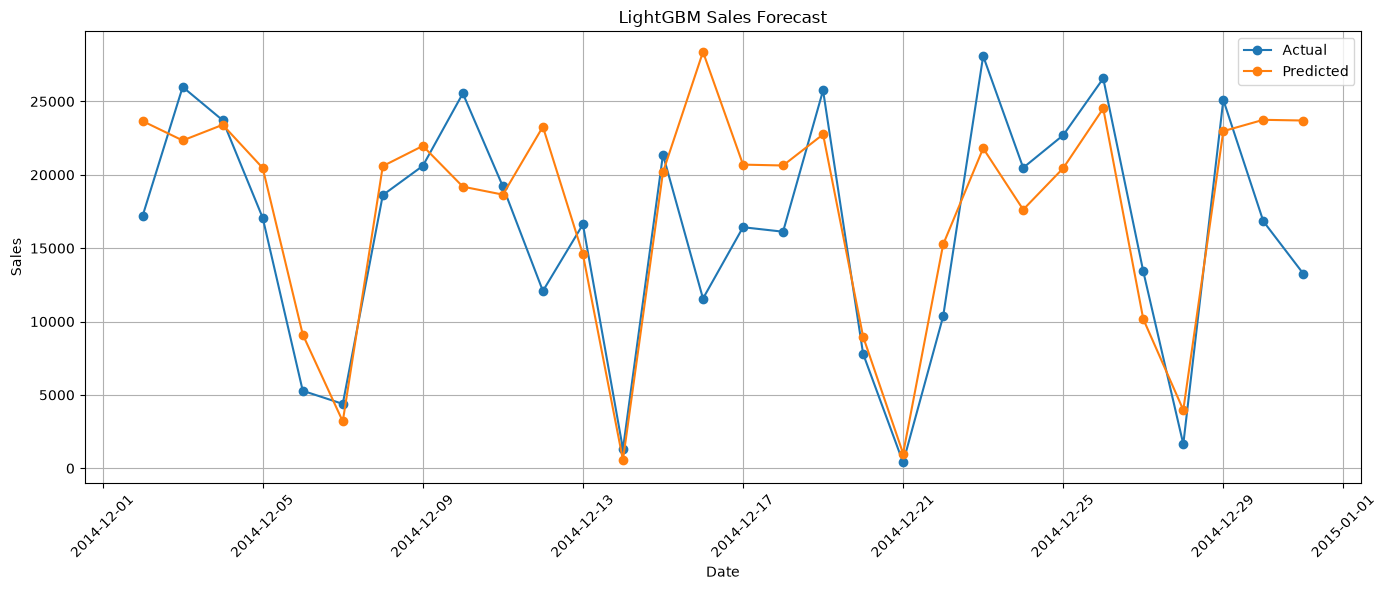


Feature Importance:
       Feature  Importance
6         lag1        1797
8        lag30        1594
7         lag7        1579
10   rolling30        1500
9     rolling7        1477
0          day         960
4   weekofyear         651
3    dayofweek         555
1        month         226
2         year         143
5      quarter           0

Forecast saved as 'lightgbm_forecast.csv'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# ===========================
# Load Dataset
# ===========================
df = pd.read_csv("C:/Users/Rakshitha/OneDrive/Desktop/infosys internship/Small-business-sales-intelligence-platform-SB7-Team4/AIML/preprocessing/daily_sales.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df = df.sort_values("Order Date")

# ===========================
# Feature Engineering
# ===========================
df["day"] = df["Order Date"].dt.day
df["month"] = df["Order Date"].dt.month
df["year"] = df["Order Date"].dt.year
df["dayofweek"] = df["Order Date"].dt.dayofweek
df["weekofyear"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["Order Date"].dt.quarter

# Lag Features
df["lag1"] = df["Total amount"].shift(1)
df["lag7"] = df["Total amount"].shift(7)
df["lag30"] = df["Total amount"].shift(30)

# Rolling Mean
df["rolling7"] = df["Total amount"].rolling(7).mean()
df["rolling30"] = df["Total amount"].rolling(30).mean()

# Remove missing values
df = df.dropna()

# ===========================
# Train-Test Split
# ===========================
train = df.iloc[:-30]
test = df.iloc[-30:]

features = [
    "day",
    "month",
    "year",
    "dayofweek",
    "weekofyear",
    "quarter",
    "lag1",
    "lag7",
    "lag30",
    "rolling7",
    "rolling30"
]

X_train = train[features]
y_train = train["Total amount"]

X_test = test[features]
y_test = test["Total amount"]

# ===========================
# Train LightGBM
# ===========================
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

# ===========================
# Prediction
# ===========================
pred = model.predict(X_test)

# ===========================
# Evaluation
# ===========================
mae = mean_absolute_error(y_test, pred) #type: ignore
rmse = np.sqrt(mean_squared_error(y_test, pred)) #type: ignore
mape = mean_absolute_percentage_error(y_test, pred) * 100 #type: ignore

print("=" * 40)
print("LightGBM Daily Forecast")
print("=" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# ===========================
# Plot
# ===========================
plt.figure(figsize=(14,6))
plt.plot(test["Order Date"], y_test.values, label="Actual", marker="o") #type: ignore
plt.plot(test["Order Date"], pred, label="Predicted", marker="o") #type: ignore
plt.title("LightGBM Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===========================
# Feature Importance
# ===========================
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

# ===========================
# Save Predictions
# ===========================
results = pd.DataFrame({
    "Date": test["Order Date"],
    "Actual": y_test.values,
    "Predicted": pred
})

results.to_csv("lightgbm_forecast.csv", index=False)

print("\nForecast saved as 'lightgbm_forecast.csv'")